Processed Corpus: [['dog', 'running', 'park'], ['cats', 'love', 'climb', 'trees'], ['pets', 'wonderful', 'companions'], ['puppy', 'baby', 'dog'], ['kittens', 'small', 'playful'], ['dogs', 'cats', 'common', 'household', 'pets']]
Training Word2Vec...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hema\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hema\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


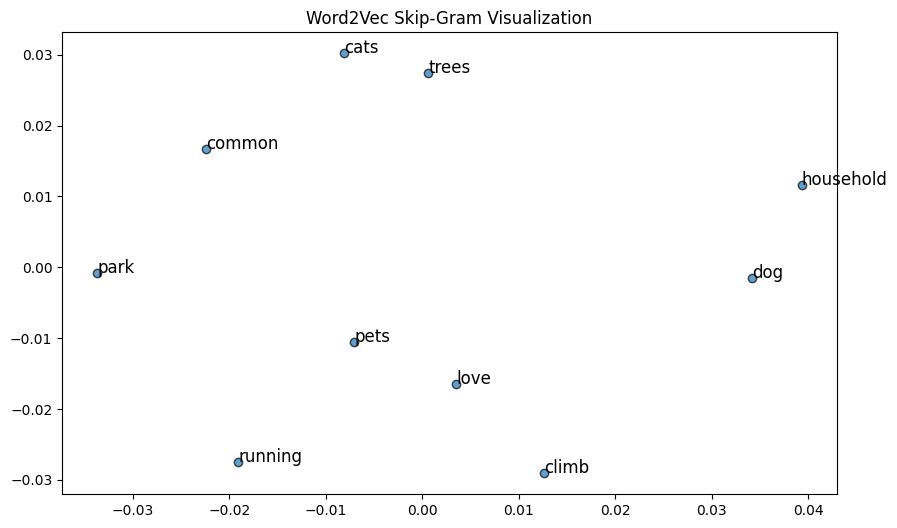

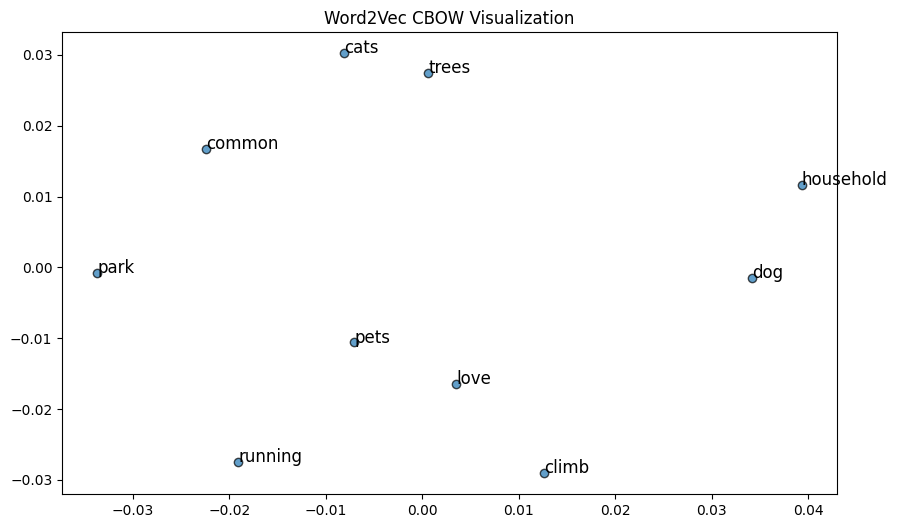

Loading GloVe Model...
[==================================================] 100.0% 128.1/128.1MB downloaded


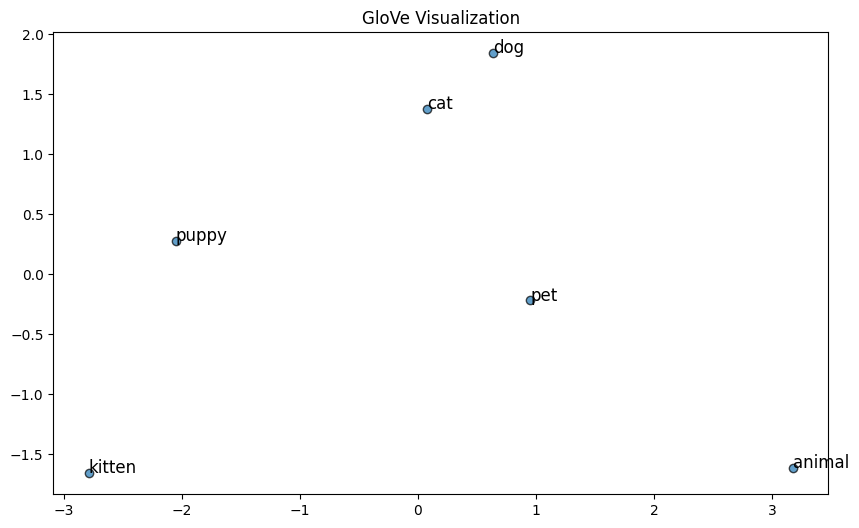

Training FastText...


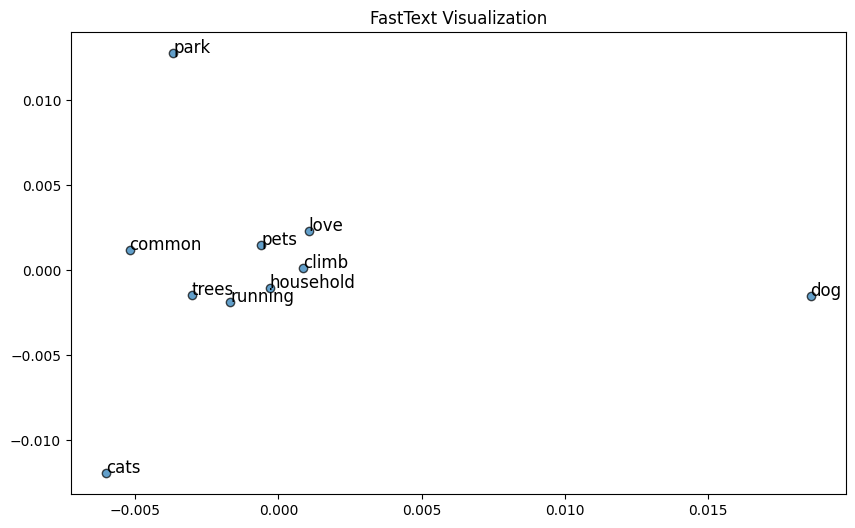

In [11]:
import re
import nltk
import string
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec, FastText
import gensim.downloader as api

nltk.download('stopwords')
nltk.download('punkt')

# Sample corpus for demonstration
corpus = [
    "The dog is running in the park.",
    "Cats love to climb trees.",
    "Pets are wonderful companions.",
    "A puppy is a baby dog.",
    "Kittens are small and playful.",
    "Dogs and cats are common household pets."
]

# Preprocess text by tokenizing and removing stopwords, punctuation
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in nltk.corpus.stopwords.words('english')]
    return tokens

# Preprocess entire corpus
def preprocess_corpus(corpus):
    return [preprocess_text(text) for text in corpus]

# Processed corpus for training
processed_corpus = preprocess_corpus(corpus)
print("Processed Corpus:", processed_corpus)

# Function to plot embeddings using PCA
def plot_embeddings(model, title="Word Embeddings"):
    words = list(model.wv.index_to_key)[:10]  # Choose top 10 words for clarity
    embeddings = np.array([model.wv[word] for word in words])

    # PCA for dimensionality reduction
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], edgecolors='k', alpha=0.7)

    for i, word in enumerate(words):
        plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), fontsize=12)

    plt.title(title)
    plt.show()

# **Word2Vec Training (Skip-gram and CBOW)**
print("Training Word2Vec...")
model_skipgram = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, sg=1, min_count=1)
model_cbow = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, sg=0, min_count=1)

plot_embeddings(model_skipgram, "Word2Vec Skip-Gram Visualization")
plot_embeddings(model_cbow, "Word2Vec CBOW Visualization")

# **GloVe Model Loading (Pre-Trained)**
print("Loading GloVe Model...")
glove_vectors = api.load("glove-wiki-gigaword-100")

# Plot GloVe embeddings using manually selected words
def plot_glove_embeddings(words):
    embeddings = np.array([glove_vectors[word] for word in words if word in glove_vectors])

    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], edgecolors='k', alpha=0.7)

    for i, word in enumerate(words):
        plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), fontsize=12)

    plt.title("GloVe Visualization")
    plt.show()

plot_glove_embeddings(["dog", "cat", "pet", "animal", "puppy", "kitten"])

# **FastText Training**
print("Training FastText...")
fasttext_model = FastText(sentences=processed_corpus, vector_size=100, window=5, min_count=1)

plot_embeddings(fasttext_model, "FastText Visualization")
